In [65]:
import matplotlib.pyplot as plt
from src.process_data import *
from IPython.display import clear_output
plt.style.use('properties.mplstyle')
from matplotlib.ticker import MultipleLocator

In [ ]:
# PROCESSING ALL FILES FOR EACH PARAMETERS
# ====== Simulation parameters ======
type_perc = 'bond'
num_colors = 3
dim = 2
L = 128
Nt = 1500
k = 1.0e-04

# List all values of rho inside folder with parameters above
rho_values = list_rho_values(type_perc, num_colors, dim, L, Nt, k, base_root="../Data")

# Creating file with all data processing
for rho in rho_values:
    path_data = f"../Data/{type_perc}_percolation/num_colors_{num_colors}/dim_{dim}/L_{L}/NT_constant/NT_{Nt}/k_{k:.1e}/rho_{rho:.1e}/data"

    all_data = glob.glob(os.path.join(path_data, "*.json"))

    out_dir = Path(path_data)
    out_dir.mkdir(parents=True, exist_ok=True)

    out_dat = out_dir / "all_data.dat"
    out_txt = out_dir / "process_names.txt"

    df, processed = saving_data(
        all_data=all_data,
        output_data=out_dat,
        output_names=out_txt,
        burn_in_frac=0.20,
        verbose=True,
        path_hint=path_data,
        force_recompute=True,   # <<<<<<<<<< força recalcular
    )

    print("Salvo em:", out_dat.resolve())
    print("Processados:", len(processed))
clear_output(wait=True)
print("All files processing")

All files processing


In [5]:
# JOIN ALL DATA PROCESSING
type_perc = 'bond'
num_colors = 3
dim = 2
L = 2000
Nt = 200
k = 1.0e-04

df_all = join_all_data(type_perc, num_colors, dim, L, Nt, k, base_root="../Data")
df_all

Salvo em: /home/junior/Documents/self_organization_percolation/Data/bond_percolation/all_data_2D.dat


,type_perc,num_colors,dim,L,Nt,k,rho,p0,order,num_samples,...,pt_erro,nt_mean,nt_erro,perc_rate,perc_ci_low,perc_ci_high,pt_mean_uncond,pt_erro_uncond,nt_mean_uncond,nt_erro_uncond
0,bond,3,2,2000,200,0.0001,0.003,0.4,1,22,...,0.002816,194.361265,1.179564,0.227273,1.012289e-01,0.434404,0.206448,0.081162,44.173015,17.367484
1,bond,3,2,2000,200,0.0001,0.003,0.4,2,22,...,NaN,NaN,NaN,0.000000,1.387779e-17,0.148660,0.000000,0.000000,0.000000,0.000000
2,bond,3,2,2000,200,0.0001,0.003,0.4,3,22,...,NaN,NaN,NaN,0.000000,1.387779e-17,0.148660,0.000000,0.000000,0.000000,0.000000
3,bond,3,2,2000,200,0.0001,0.003,0.5,1,20,...,0.002608,191.887922,2.029277,1.000000,8.388699e-01,1.000000,0.916450,0.002608,191.887922,2.029277
4,bond,3,2,2000,200,0.0001,0.003,0.5,2,20,...,0.001478,192.424168,2.841733,0.600000,3.865779e-01,0.781196,0.549305,0.100293,115.454501,21.147858
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,bond,3,2,2000,200,0.0001,0.330,0.8,2,20,...,NaN,NaN,NaN,0.000000,0.000000e+00,0.161130,0.000000,0.000000,0.000000,0.000000
296,bond,3,2,2000,200,0.0001,0.330,0.8,3,20,...,NaN,NaN,NaN,0.000000,0.000000e+00,0.161130,0.000000,0.000000,0.000000,0.000000
297,bond,3,2,2000,200,0.0001,0.330,1.0,1,100,...,NaN,NaN,NaN,0.000000,0.000000e+00,0.036995,0.000000,0.000000,0.000000,0.000000
298,bond,3,2,2000,200,0.0001,0.330,1.0,2,100,...,NaN,NaN,NaN,0.000000,0.000000e+00,0.036995,0.000000,0.000000,0.000000,0.000000


In [ ]:
df_clean = df_all[df_all[["pt_mean", "nt_mean"]].notna().all(axis=1)]
df_clean.loc[:, "rho":"nt_erro"].sort_values(by=["rho", "p0"])

,rho,p0,order,num_samples,num_sample_perc,pt_mean,pt_erro,nt_mean,nt_erro
0,0.003,0.4,1,22,5,0.908370,0.002816,194.361265,1.179564
3,0.003,0.5,1,20,20,0.916450,0.002608,191.887922,2.029277
4,0.003,0.5,2,20,12,0.915509,0.001478,192.424168,2.841733
5,0.003,0.5,3,20,6,0.918368,0.002620,199.855251,0.038917
6,0.003,0.7,1,100,100,0.923992,0.000430,199.306918,0.127607
...,...,...,...,...,...,...,...,...,...
108,0.120,0.5,1,20,1,0.999580,0.000000,106.448556,0.000000
111,0.120,0.7,1,100,8,0.999348,0.000301,99.039740,8.601468
114,0.120,0.8,1,20,2,0.999698,0.000269,90.956154,12.398664
117,0.120,1.0,1,100,14,0.999396,0.000090,97.995344,4.345035


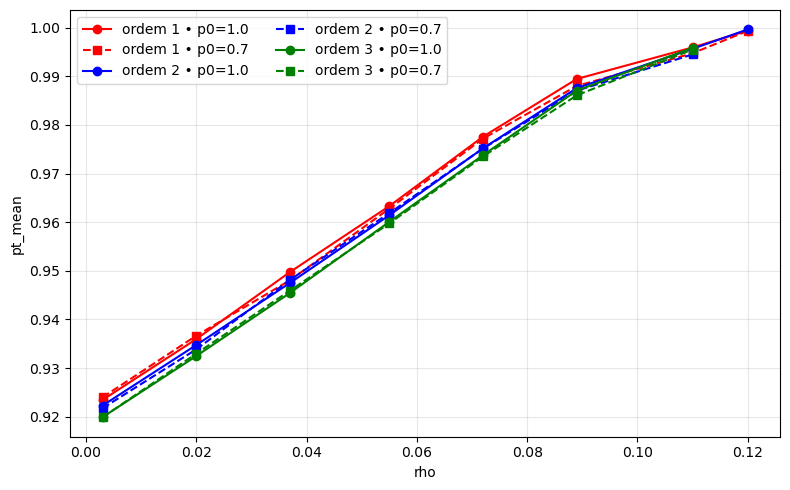

In [11]:
type_perc = 'bond'
num_colors = 3
dim = 2
L = 2000
Nt = 200
k = 1.0e-04

rho_values = list_rho_values(type_perc, num_colors, dim, L, Nt, k, base_root="../Data")

# sub-dataframe já limpo (sem "Null" strings), e só rhos de interesse
df_sub = df_clean[df_clean["rho"].isin(rho_values)].copy()

# garanta comparação estável de p0
df_sub["p0"] = df_sub["p0"].round(1)

orders = [1, 2, 3]
colors = ["red", "blue", "green"]
markers = {1.0: "o", 0.7: "s"}     # marcador diferente por p0
linestyles = {1.0: "-", 0.7: "--"} # estilo diferente por p0
p0_list = [1.0, 0.7]

# eixo x comum (todos rhos presentes no df_sub) – ordenado
rhos = np.sort(df_sub["rho"].unique())

plt.figure(figsize=(8,5))

for idx, order in enumerate(orders):
    for p0 in p0_list:
        # série pt_mean indexada por rho, reindexada para ter MESMOS x
        s = (df_sub[(df_sub["order"] == order) & (df_sub["p0"].eq(p0))]
                .set_index("rho")["pt_mean"]
                .reindex(rhos))  # insere NaN onde não existir

        plt.plot(
            rhos, s.values,
            marker=markers[p0], linestyle=linestyles[p0],
            color=colors[idx],
            label=f"ordem {order} • p0={p0:.1f}"
        )

plt.xlabel("rho")
plt.ylabel("pt_mean")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


0.5890538680852977
0.5890538680852977
0.5890538680852977
0.5890538680852977
0.5229495378016646
0.5229495378016646
0.5229495378016646
0.5229495378016646
0.5491231947258898
0.5491231947258898
0.5491231947258898
0.5491231947258898


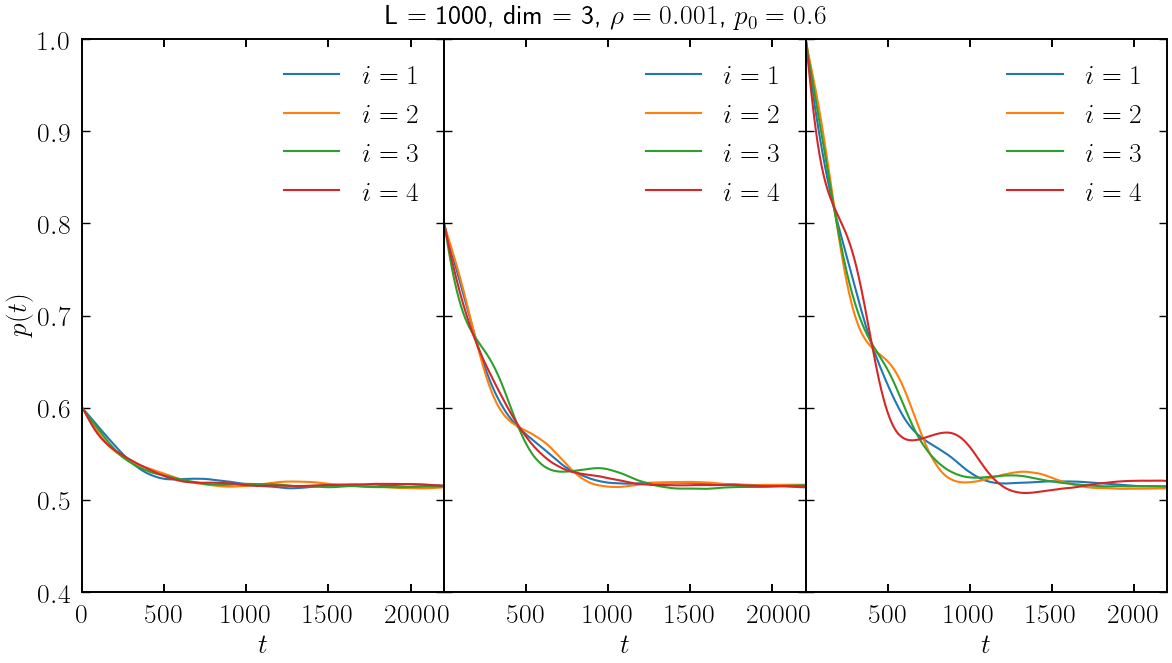

In [ ]:
type_perc = "bond"
num_colors = 4
dim = 3
L = 1000
NT = 12000
k=1.0e-08
rho=1.0e-03
#p0 = 0.60
seed = 1304039063
p0_lst = [0.6, 0.8, 1.0]
seed_name = [14574188, 344587444, 198323458]


colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
markers = ["*", "^", "o", "d"]
fontsize_ticks = 13
thickness = 1.4


fig, axes = plt.subplots(1,3, sharex=True, sharey=True ,figsize=(14,7))
fig.subplots_adjust(wspace=0, hspace=0)
for index, ax in enumerate(axes):
    data = data_single_sample(type_perc, num_colors, dim, L, NT, k, rho, p0_lst[index], seed_name[index])
        
    
    #ax.axhline(y=NT, xmin=min(data["t"]), xmax=max(data["t"]), linewidth=thickness, color='k', ls="dashed", label="_nolegend_")
    for i in range(1,5):
        ax.plot(data["t"], data[f"p_{i}"], '-', label=f"$i = {i}$")
        
    
    ax.legend(fontsize=20)
    
    #ax.set_xlim([min(data["t"]), max(data["t"])])
    ax.set_xlabel("$t$")
    
    
    ax.xaxis.set_major_locator(MultipleLocator(500))
    #     ax.tick_params(axis="both", which="major", labelsize=18)
    
    ax.set_xlim([0, max(data['t'])])
    ax.set_ylim([0.4, 1.0])
    a = np.mean(data[f"p_{i}"])
    
axes[0].set_ylabel(r"$p(t)$")
fig.suptitle(f"L = {L}, dim = {dim},  $\\rho = {rho}$, $p_0 = {p0}$", fontsize=20, fontweight="bold", y=0.95)  # título comum
fig.subplots_adjust(top=0.90)  # abre espaço no topo para o título
plt.show()

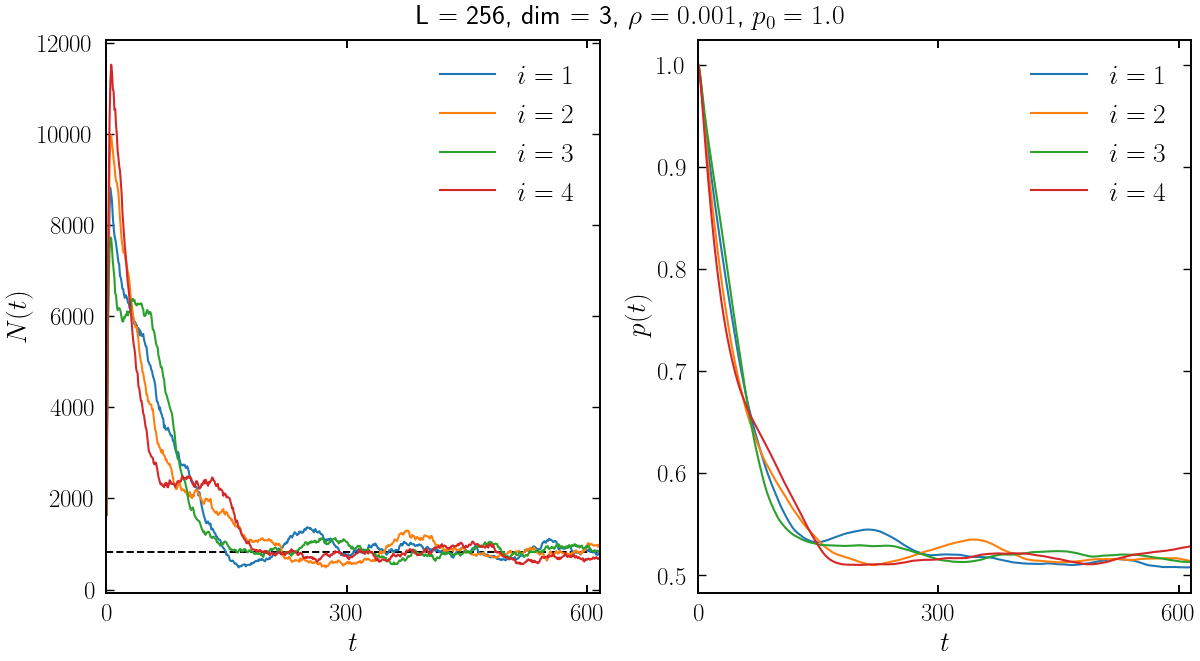

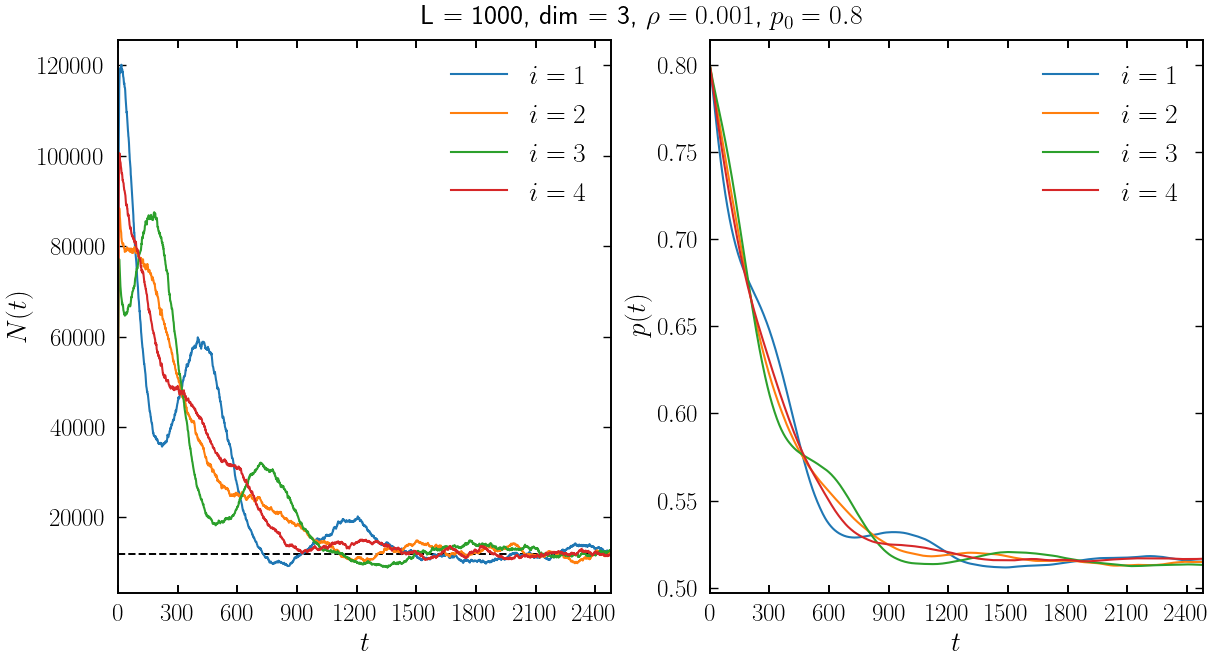

In [ ]:
type_perc = "bond"
num_colors = 4
dim = 3
L = 1000
NT = 12000
k=1.0e-08
rho=1.0e-03
p0 = 0.80
seed = 1975277821

data = data_single_sample(type_perc, num_colors, dim, L, NT, k, rho, p0, seed)

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fontsize_ticks = 13
thickness = 1.4

fig, axes = plt.subplots(1,2, figsize=(14,7))

handles, labels = [], []
for index, ax in enumerate(axes):
    if index == 1:
        prop = "p"
        label_y = r"$p(t)$"
        
    else:
        prop = "N"
        label_y = r"$N(t)$"
        ax.axhline(y=NT, xmin=min(data["t"]), xmax=max(data["t"]), linewidth=thickness, color='k', ls="dashed", label="_nolegend_")
    for i in range(1,5):
        ax.plot(data["t"], data[f"{prop}_{i}"], '-', label=f"$i = {i}$")
    
    ax.legend(fontsize=20)
    ax.set_ylabel(label_y)
    ax.set_xlim([min(data["t"]), max(data["t"])])
    ax.set_xlabel("$t$")
    
    for ax in axes.ravel():
        ax.xaxis.set_major_locator(MultipleLocator(300))
        ax.tick_params(axis="both", which="major", labelsize=18)

fig.suptitle(f"L = {L}, dim = {dim},  $\\rho = {rho}$, $p_0 = {p0}$", fontsize=20, fontweight="bold", y=0.95)  # título comum
fig.subplots_adjust(top=0.90)  # abre espaço no topo para o título

plt.show()

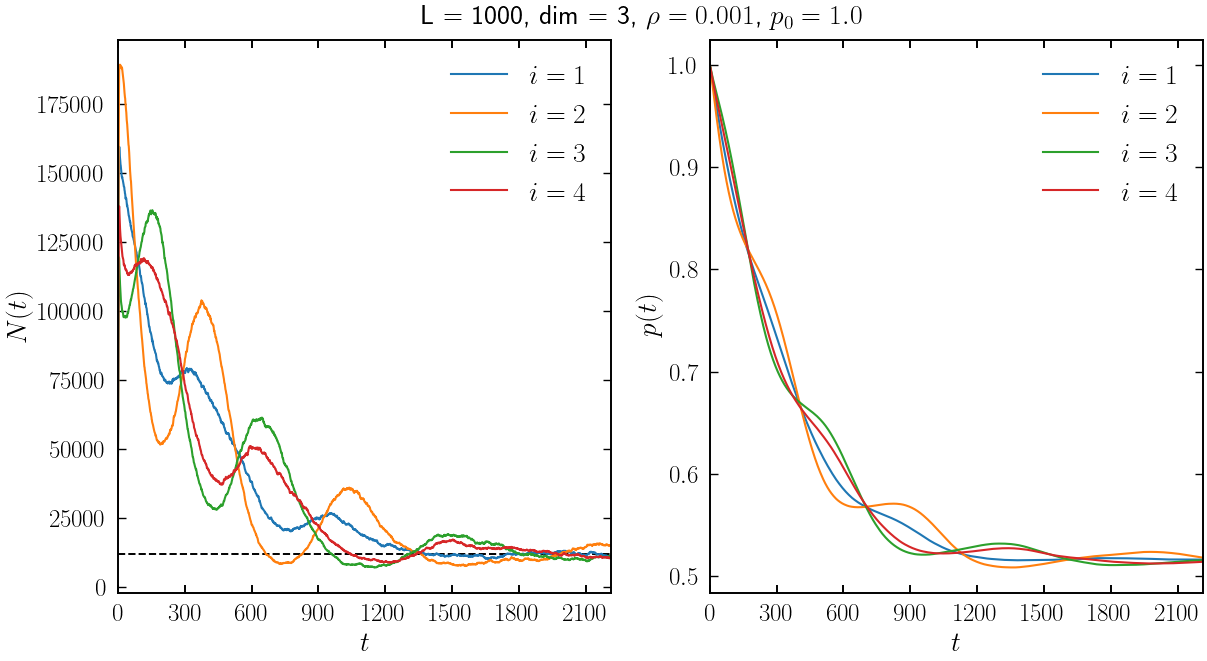

In [64]:
type_perc = "bond"
num_colors = 4
dim = 3
L = 1000
NT = 12000
k=1.0e-08
rho=1.0e-03
p0 = 1.00
seed = 535494239

data = data_single_sample(type_perc, num_colors, dim, L, NT, k, rho, p0, seed)

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fontsize_ticks = 13
thickness = 1.4

fig, axes = plt.subplots(1,2, figsize=(14,7))

handles, labels = [], []
for index, ax in enumerate(axes):
    if index == 1:
        prop = "p"
        label_y = r"$p(t)$"
        
    else:
        prop = "N"
        label_y = r"$N(t)$"
        ax.axhline(y=NT, xmin=min(data["t"]), xmax=max(data["t"]), linewidth=thickness, color='k', ls="dashed", label="_nolegend_")
    for i in range(1,5):
        ax.plot(data["t"], data[f"{prop}_{i}"], '-', label=f"$i = {i}$")
    
    ax.legend(fontsize=20)
    ax.set_ylabel(label_y)
    ax.set_xlim([min(data["t"]), max(data["t"])])
    ax.set_xlabel("$t$")
    
    for ax in axes.ravel():
        ax.xaxis.set_major_locator(MultipleLocator(300))
        ax.tick_params(axis="both", which="major", labelsize=18)

fig.suptitle(f"L = {L}, dim = {dim},  $\\rho = {rho}$, $p_0 = {p0}$", fontsize=20, fontweight="bold", y=0.95)  # título comum
fig.subplots_adjust(top=0.90)  # abre espaço no topo para o título

plt.show()

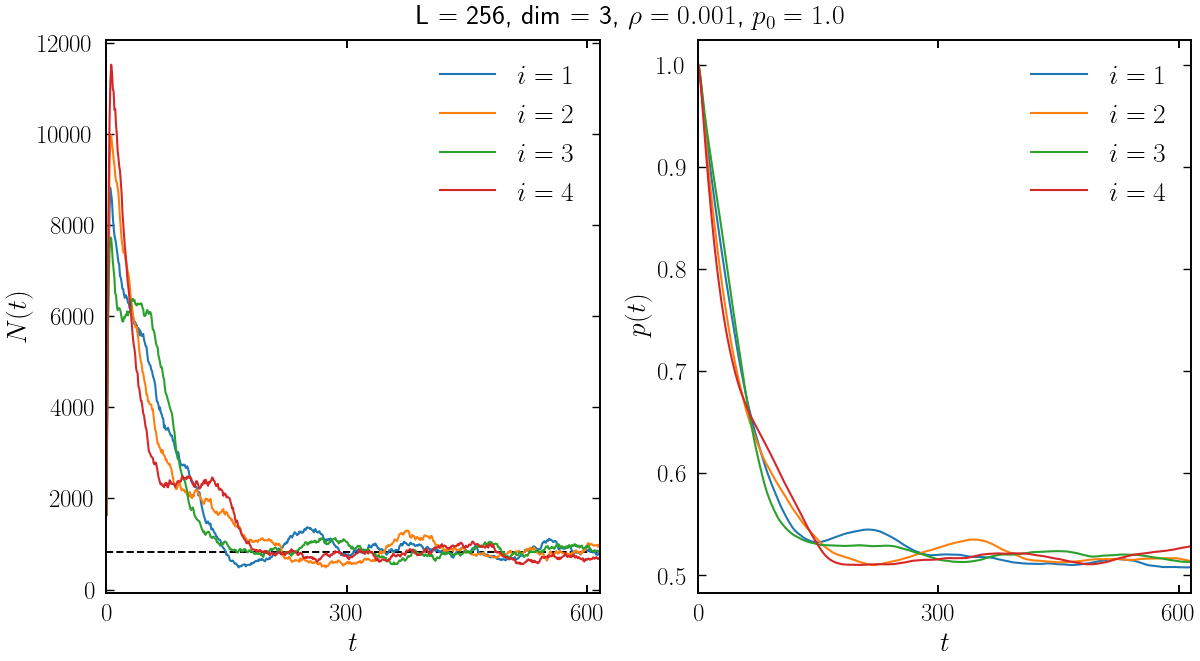

In [74]:
type_perc = "bond"
num_colors = 4
dim = 3
L = 256
NT = 820
k=1.0e-06
rho=1.0e-03
p0 = 1.00
seed = 1055002752
#seed = 665884593

data = data_single_sample(type_perc, num_colors, dim, L, NT, k, rho, p0, seed)

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fontsize_ticks = 13
thickness = 1.4

fig, axes = plt.subplots(1,2, figsize=(14,7))

handles, labels = [], []
for index, ax in enumerate(axes):
    if index == 1:
        prop = "p"
        label_y = r"$p(t)$"
        
    else:
        prop = "N"
        label_y = r"$N(t)$"
        ax.axhline(y=NT, xmin=min(data["t"]), xmax=max(data["t"]), linewidth=thickness, color='k', ls="dashed", label="_nolegend_")
    for i in range(1,5):
        ax.plot(data["t"], data[f"{prop}_{i}"], '-', label=f"$i = {i}$")
    
    ax.legend(fontsize=20)
    ax.set_ylabel(label_y)
    ax.set_xlim([min(data["t"]), max(data["t"])])
    ax.set_xlabel("$t$")
    
    for ax in axes.ravel():
        ax.xaxis.set_major_locator(MultipleLocator(300))
        ax.tick_params(axis="both", which="major", labelsize=18)

fig.suptitle(f"L = {L}, dim = {dim},  $\\rho = {rho}$, $p_0 = {p0}$", fontsize=20, fontweight="bold", y=0.95)  # título comum
fig.subplots_adjust(top=0.90)  # abre espaço no topo para o título

plt.show()